In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

# Paths (run from notebooks/)
base = Path("..")

phaseA_perq_path = base / "report/phaseA_report_perq.tsv"  # retrieval
phaseB_perq_path = base / "report/phaseB_report_perq.tsv"  # generation

phaseA_perq = pd.read_csv(phaseA_perq_path, sep="\t")
phaseB_perq = pd.read_csv(phaseB_perq_path, sep="\t")

# Align on split + question_id
perq_merged = phaseA_perq.merge(
    phaseB_perq,
    on=["split", "question_id"],
    how="inner",
    suffixes=("_retr", "_gen"),
)

# Select retrieval d_MAP and generation recall metrics
retr_col = "d_MAP_retr" if "d_MAP_retr" in perq_merged.columns else "d_MAP"
r2_col = "R_2_Rec"
su4_col = "R_SU4_Rec"

# Clean and drop rows with missing values in the used columns
valid = (
    perq_merged[[retr_col, r2_col, su4_col]]
    .replace({"NA": np.nan})
    .astype(float)
    .dropna()
)

print(f"Valid rows for correlation: {len(valid)}")

corr_r2 = valid[[retr_col, r2_col]].corr(method="pearson").iloc[0, 1]
corr_su4 = valid[[retr_col, su4_col]].corr(method="pearson").iloc[0, 1]

print("Pearson corr(d_MAP, R_2_Rec):  ", corr_r2)
print("Pearson corr(d_MAP, R_SU4_Rec):", corr_su4)

valid[[retr_col, r2_col, su4_col]].describe()

Valid rows for correlation: 699
Pearson corr(d_MAP, R_2_Rec):   0.23840811161910744
Pearson corr(d_MAP, R_SU4_Rec): 0.24161286126448453


,d_MAP,R_2_Rec,R_SU4_Rec
count,699.000000,699.000000,699.000000
mean,0.338134,0.242592,0.268912
std,0.335411,0.237795,0.224677
min,0.000000,0.000000,0.000000
25%,0.050000,0.067647,0.107246
50%,0.234444,0.166667,0.200000
75%,0.514722,0.346327,0.364358
max,1.000000,1.000000,1.000000


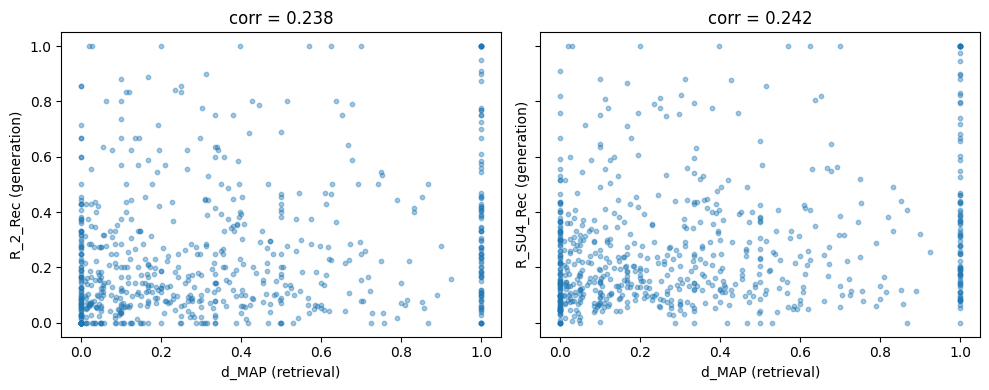

In [2]:
# Quick scatter plots: retrieval d_MAP vs generation recall

fig, axes = plt.subplots(1, 2, figsize=(10, 4), sharey=True)

axes[0].scatter(valid[retr_col], valid[r2_col], alpha=0.4, s=10)
axes[0].set_xlabel("d_MAP (retrieval)")
axes[0].set_ylabel("R_2_Rec (generation)")
axes[0].set_title(f"corr = {corr_r2:.3f}")

axes[1].scatter(valid[retr_col], valid[su4_col], alpha=0.4, s=10)
axes[1].set_xlabel("d_MAP (retrieval)")
axes[1].set_ylabel("R_SU4_Rec (generation)")
axes[1].set_title(f"corr = {corr_su4:.3f}")

plt.tight_layout()
plt.show()